**Imports**

In [1]:
import pandas as pd
import tensorflow as tf
import numpy as np
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import regularizers
from sklearn.model_selection import train_test_split
import sys
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import classification_report
from sklearn.metrics import recall_score
from sklearn.metrics import precision_score
from sklearn.metrics import f1_score
from keras.optimizers import Adam
from sklearn.preprocessing import LabelEncoder


**Deliverable 1: Data Loading and Preprocessing**

Step 1.1: Load CSV file

In [2]:
train_df = pd.read_csv("sign_mnist_train.csv")
test_df = pd.read_csv("sign_mnist_test.csv")

print(train_df.shape, test_df.shape)
train_df.head()

(27455, 785) (7172, 785)


,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,3,107,118,127,134,139,143,146,150,153,...,207,207,207,207,206,206,206,204,203,202
1,6,155,157,156,156,156,157,156,158,158,...,69,149,128,87,94,163,175,103,135,149
2,2,187,188,188,187,187,186,187,188,187,...,202,201,200,199,198,199,198,195,194,195
3,2,211,211,212,212,211,210,211,210,210,...,235,234,233,231,230,226,225,222,229,163
4,13,164,167,170,172,176,179,180,184,185,...,92,105,105,108,133,163,157,163,164,179


Had initial problems with setting up correct environment; checking to see if correct Python version is running (3.11 for tensor flow)

In [3]:
print(sys.executable)
print(sys.version)

/Users/fionac./nlpcv/tf-venv/bin/python
3.11.4 (v3.11.4:d2340ef257, Jun  6 2023, 19:15:51) [Clang 13.0.0 (clang-1300.0.29.30)]


In [4]:
num_classes = 24
# 24 classes (a-z excluding j&z), needing 25 in order for 24 to be a valid index
input_shape = (28, 28, 1)
# 28 by 28 pixels, one channel bc grayscale image

#split train and test sets
y_train = train_df["label"].values
x_train = train_df.drop("label", axis=1).values

y_test = test_df["label"].values
x_test = test_df.drop("label", axis=1).values

# fixing issue with label allignments when printing confusion matrix and fitting model due to two classes being skipped
labe = LabelEncoder()

y_train = labe.fit_transform(y_train)
y_test = labe.fit_transform(y_test)
print(np.unique(y_train))

[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23]


Step 1.2: Normalize pixel values to [0,1]

In [5]:
x_train = x_train.astype("float32") / 255
x_test = x_test.astype("float32") / 255

#reshape 
x_train = x_train.reshape(-1, 28, 28)
x_test = x_test.reshape(-1, 28, 28)

#ensuring images have correct shape
x_train = np.expand_dims(x_train, -1)
x_test = np.expand_dims(x_test, -1)
print("x_train shape:", x_train.shape)
print(x_train.shape[0], "train samples")
print(x_test.shape[0], "test samples")

x_train shape: (27455, 28, 28, 1)
27455 train samples
7172 test samples


I displayed a few samples of the training dataset, in order to understand the features of the data I was working with.

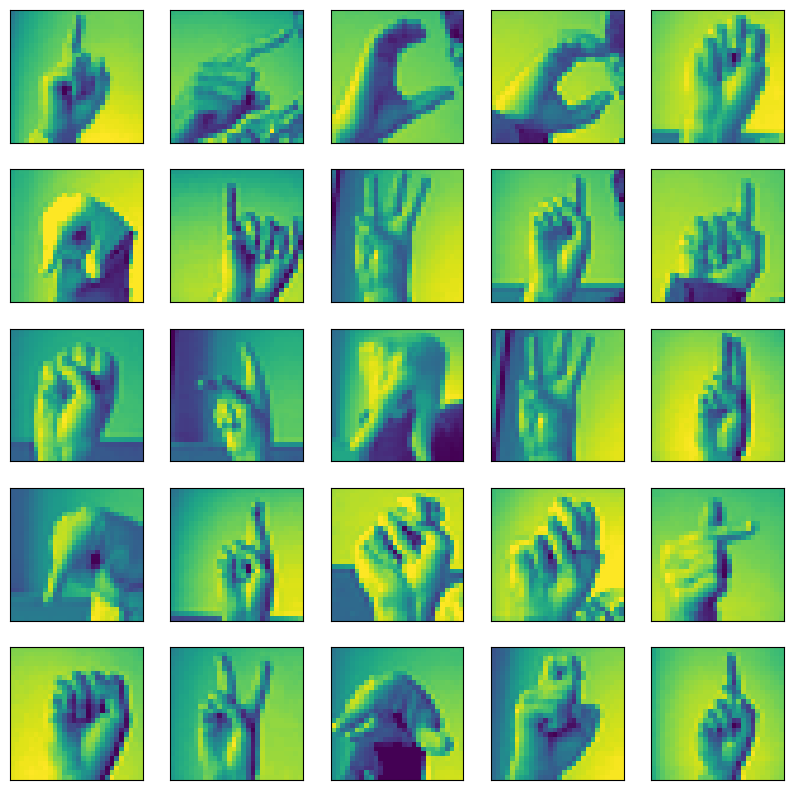

In [6]:
plt.figure(figsize=(10,10))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(np.squeeze(x_train[i,:,:,:]))
plt.show()
# view samples of ASL signs

Step 1.3: Creating validation split from train set

In [7]:
x_train, x_val, y_train, y_val = train_test_split(x_train, y_train, test_size=0.2, random_state=42, stratify=y_train)
# stratify with y_train to make sure class distribution matches original dataset
y_val = labe.fit_transform(y_val)
print("Train:", x_train.shape)
print("Val:", x_val.shape)
print("Test:", x_test.shape)

Train: (21964, 28, 28, 1)
Val: (5491, 28, 28, 1)
Test: (7172, 28, 28, 1)


**Deliverable 2: CNN Architectures**

Step 2.1: Baseline CNN architecture

In [8]:
model_base = tf.keras.Sequential(
    [
        tf.keras.Input(shape=input_shape),
        layers.Conv2D(32, kernel_size=(3, 3), activation="relu"),
        layers.Conv2D(32, kernel_size=(3, 3), activation="relu"),
        layers.MaxPooling2D(pool_size=(2, 2)),
        layers.Flatten(),
        layers.Dense(num_classes, activation="softmax"),
    ]
)
model_base.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 24, 24, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 12, 12, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 24)             │       110,616 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 120,184 (469.47 KB)

 Trainable params: 120,184 (469.47 KB)

 Non-trainable params: 0 (0.00 B)

Step 2.2: Enhanced CNN architecture - VGG-style Network 

Step 3.1 (Description)
- When creating the enhanced CNN architecture, in line with a VGG-style network, I started out with three convolutional blocks, followed by a fully connected layer at the end. The blocks each had two convolutional layers, followed by a max pooling layer in order to add more depth within the feature extraction before downsampling to the most relevant information. I started these blocks with 32 filters, then increased to 64 and 128 for the next blocks. With three blocks, I found that my model was not outperforming my baseline model. I decided to condense my model to two convolutional blocks, which alligned better with the size and simplicity of the dataset, and found this to improve my accuracy before adding in further tuning. I also ran different variations of the model starting the filter size at 16, rather than 32, but found the most optimal pattern to be doubling the size by two each time, beginning at 32. 
- For each convolutional layer, I applied the same hyperparameters. I used a kernel size of (3,3), as this was small enough to capture the details of the dataset. I thought back to our lecture and how we utilized the image of the matrix of squares sliding across the image, and referred back to past workshops where this was the baseline number we used for many models. The activation function used was "relu", which incorporates non-linearity, allowing the model to learn more complex patterns, and is an efficient choice for many neural networks. Next, I set padding to "same" which keeps the output size to be (28,28) so important spatial information isn't lost. Finally, I used L2 kernel regularization at the value (0.0001), to help avoid overfitting. I experimented with 0.001 and 0.0001, but found that a smaller learning rate drastically improved the accuracy for this model. After each convolutional layer I added a batch normalization layer that helped stabilize training by normalizing the output of each batch. I ended each block with a dropout layer of 0.3. Adding this hyperparameter made my accuracy increase by 3%, and is a large factor of controlling overfitting. In my model, this technique dropped 30% of neurons during training. This helps the model not memorize the data and learn more general patterns.

In [9]:
datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=False
)
datagen.fit(x_train)

In [10]:
model_vgg = tf.keras.Sequential(
    [
        # first block
        tf.keras.Input(shape=input_shape),
        layers.Conv2D(32, kernel_size=(3, 3), activation="relu", padding="same", kernel_regularizer=regularizers.l2(0.0001)),
        layers.BatchNormalization(),
        layers.Conv2D(32, kernel_size=(3, 3), activation="relu", padding="same", kernel_regularizer=regularizers.l2(0.0001)),
        layers.BatchNormalization(),
        layers.MaxPooling2D(pool_size=(2, 2)),
        layers.Dropout(0.3),

        # second block
        layers.Conv2D(64, kernel_size=(3, 3), activation="relu", padding="same", kernel_regularizer=regularizers.l2(0.0001)),
        layers.BatchNormalization(),
        layers.Conv2D(64, kernel_size=(3, 3), activation="relu", padding="same", kernel_regularizer=regularizers.l2(0.0001)),
        layers.BatchNormalization(),
        layers.MaxPooling2D(pool_size=(2, 2)),
        layers.Dropout(0.3),

        layers.Flatten(),
        layers.Dense(128, activation="relu", kernel_regularizer=regularizers.l2(0.0001)),
        layers.BatchNormalization(),
        layers.Dropout(0.3),
        layers.Dense(num_classes, activation="softmax"),

    ]
)
model_vgg.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 14, 14, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │       401,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 24)             │         3,096 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 470,904 (1.80 MB)

 Trainable params: 470,264 (1.79 MB)

 Non-trainable params: 640 (2.50 KB)

Step 2.3: Justify design choices
- I chose to implement a VGG-style network to increase the depth of the model and enhance feature extraction. This type of neural network works especially well for classification based tasks, which aligns with goal of this model to correctly depict what letter in the ASL alphabet is presented in each image. This type of model also allowed me to explore various possibilites with the number of convolutional layers and other hyperparameters, which created a final model that was able to be fine tuned and flexible. 

**Deliverable 3: Training, Testing, and Evaluation**

Step 3.1: 
- The first hyperparameter I used for the VGGNet Model was to set the loss and optimizer values when compiling the model. I chose to use Adam because we have used it many times it class, as it is known to be a great optimizer for many different neural networks tasks. I experimented with trying SGD as an optimizer, but the accuracy drastically dropped, with the first epoch only having a 0.1% accuracy compared to 83% when using Adam.
- I also chose to implement the loss function to be be 'sparse_categorical_crossentropy', as it is well suited for multi-class classification tasks.
- I chose to use a batch size of 80, because I found that a smaller size led to a better test performance, despite running slightly slower. In this sense, I favored that the model produced better results, in a trade off for a longer runtime. I experimented with 64, 128, and 256, which were all baselines we used for many tasks in class. This model ran the best when finding an equillibrium between 64 and 128. 

In [11]:
model_base.compile(
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model_vgg.compile(
    loss='sparse_categorical_crossentropy',
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    metrics=['accuracy']
)

In [ ]:
history_base = model_base.fit(x_train, y_train, batch_size=80, epochs=15, validation_data=(x_val, y_val))

Epoch 1/15
220/220 ━━━━━━━━━━━━━━━━━━━━ 8s 36ms/step - accuracy: 0.6359 - loss: 1.3401 - val_accuracy: 0.9179 - val_loss: 0.3438
Epoch 2/15
220/220 ━━━━━━━━━━━━━━━━━━━━ 7s 31ms/step - accuracy: 0.9681 - loss: 0.1438 - val_accuracy: 0.9883 - val_loss: 0.0505
Epoch 3/15
220/220 ━━━━━━━━━━━━━━━━━━━━ 6s 28ms/step - accuracy: 0.9977 - loss: 0.0160 - val_accuracy: 0.9998 - val_loss: 0.0071
Epoch 4/15
220/220 ━━━━━━━━━━━━━━━━━━━━ 6s 29ms/step - accuracy: 0.9999 - loss: 0.0022 - val_accuracy: 1.0000 - val_loss: 5.0198e-04
Epoch 5/15
220/220 ━━━━━━━━━━━━━━━━━━━━ 6s 29ms/step - accuracy: 0.9999 - loss: 6.9476e-04 - val_accuracy: 1.0000 - val_loss: 2.1156e-04
Epoch 6/15
220/220 ━━━━━━━━━━━━━━━━━━━━ 6s 28ms/step - accuracy: 1.0000 - loss: 1.0864e-04 - val_accuracy: 1.0000 - val_loss: 9.0927e-05
Epoch 7/15
220/220 ━━━━━━━━━━━━━━━━━━━━ 7s 31ms/step - accuracy: 1.0000 - loss: 6.1290e-05 - val_accuracy: 1.0000 - val_loss: 5.9702e-05
Epoch 8/15
220/220 ━━━━━━━━━━━━━━━━━━━━ 6s 28ms/step - accuracy: 1.00

In [13]:
score = model_base.evaluate(x_test, y_test, verbose=0)
print("Base model test loss:", score[0])
print("Base model test accuracy:", score[1])

Base model test loss: 1.3684697151184082
Base model test accuracy: 0.8434188365936279


Step 3.1 (continued): 
- To increase my accuracy even further, I used a technique from workshop five: data augmentation. This allowed me to apply augmentation to the training set. I used the same parameters as we did in the workshop, as it utilized an MNIST dataset as well for a classification task. However, I set 'horizontal flip' to false, because sign language images cannot be flipped and maintain the same meaning. This step alone helped increase my accuracy by 2%, and helped diversify the training set by altering the given samples of data.
- Before fitting the model, I implemented an 'Early Stopping' regularization technique, to increase the efficiency of the model. With a patience parameter set to 3, the model will stop training if the validation loss continues to decrease after the span of 3 epochs. This helps prevent the model from overfitting, and also helps improve runtime. With an epoch number of 15 total, a patience of 5 epochs was a good baseline that I started with, but I found that if I wanted to value efficiency in runtime slightly more, I could decrease the patience while still maintaining the accuracy I attained at previously. 
- While fitting the model, I chose to set the epochs to 15, as I wanted to balance the tradeoff between the time it took to run and the accuracy. I experiemented with various epochs, first beginning at 100 epochs, which took over 20 minutes to run. As I began finetuning other hyperparameters, I decreased the epochs so I could try various metrics in my model without having to wait a long duration each time to see results. I ran many instances of the model at 20-25 epochs, but noticed that the accuracy was peaking towards the middle of the runtime, which allowed me to adjust the epochs down even further, saving computational power while still maintaining accuracy. 

In [ ]:
early = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True,
    verbose=1
)

history_vgg = model_vgg.fit(x_train, y_train, batch_size=80, epochs=15, validation_data=(x_val, y_val), callbacks=early)

Epoch 1/15
220/220 ━━━━━━━━━━━━━━━━━━━━ 26s 108ms/step - accuracy: 0.7986 - loss: 0.7642 - val_accuracy: 0.0885 - val_loss: 4.0899
Epoch 2/15
220/220 ━━━━━━━━━━━━━━━━━━━━ 25s 114ms/step - accuracy: 0.9902 - loss: 0.1106 - val_accuracy: 0.7873 - val_loss: 0.8166
Epoch 3/15
220/220 ━━━━━━━━━━━━━━━━━━━━ 23s 106ms/step - accuracy: 0.9977 - loss: 0.0662 - val_accuracy: 1.0000 - val_loss: 0.0481
Epoch 4/15
220/220 ━━━━━━━━━━━━━━━━━━━━ 25s 115ms/step - accuracy: 0.9988 - loss: 0.0544 - val_accuracy: 1.0000 - val_loss: 0.0413
Epoch 5/15
220/220 ━━━━━━━━━━━━━━━━━━━━ 23s 105ms/step - accuracy: 0.9994 - loss: 0.0483 - val_accuracy: 1.0000 - val_loss: 0.0396
Epoch 6/15
220/220 ━━━━━━━━━━━━━━━━━━━━ 24s 109ms/step - accuracy: 0.9990 - loss: 0.0454 - val_accuracy: 1.0000 - val_loss: 0.0376
Epoch 7/15
220/220 ━━━━━━━━━━━━━━━━━━━━ 26s 119ms/step - accuracy: 0.9997 - loss: 0.0407 - val_accuracy: 1.0000 - val_loss: 0.0357
Epoch 8/15
220/220 ━━━━━━━━━━━━━━━━━━━━ 22s 100ms/step - accuracy: 0.9995 - loss: 0

In [15]:
score = model_vgg.evaluate(x_test, y_test, verbose=0)
print("VGG model test loss:", score[0])
print("VGG model test accuracy:", score[1])
# baseline model had test loss of 0.93 and test acc of 0.84
# new model had test loss of 1.23 and test acc of 0.88
# adding drop out helped so much! 0.94 accuracy and test loss of 0.33 (0.3 dropout)
# even better with 0.5 dropout! 0.96 acc and test loss of 0.18
# 0.97 acc with adding 0.0001 l2 regularization
# 0.973 acc and .136 test loss woith dropout of 0.3!

VGG model test loss: 0.15475310385227203
VGG model test accuracy: 0.9542666077613831


Step 3.2: 
- When running both the base model and VGGnet model, I noticed several differences and improvements between the runtimes. The base model ran much quicker, and only took around 1 minute 40 seconds to run. This is due to the model being much simpler, and not having many layers to parse through. However, the test accuracy was only around 84%, and the test loss was very high, around 1.43. When running the VGG net, the time to run increased to just around 6 minutes, but the test accuracy rose to around 96%, and the test loss dropped to 0.12. The accuracy and test loss tended to vary slightly between each run. The accuracy specfically can change around +-1%, based on the variability in samples of the dataset. 

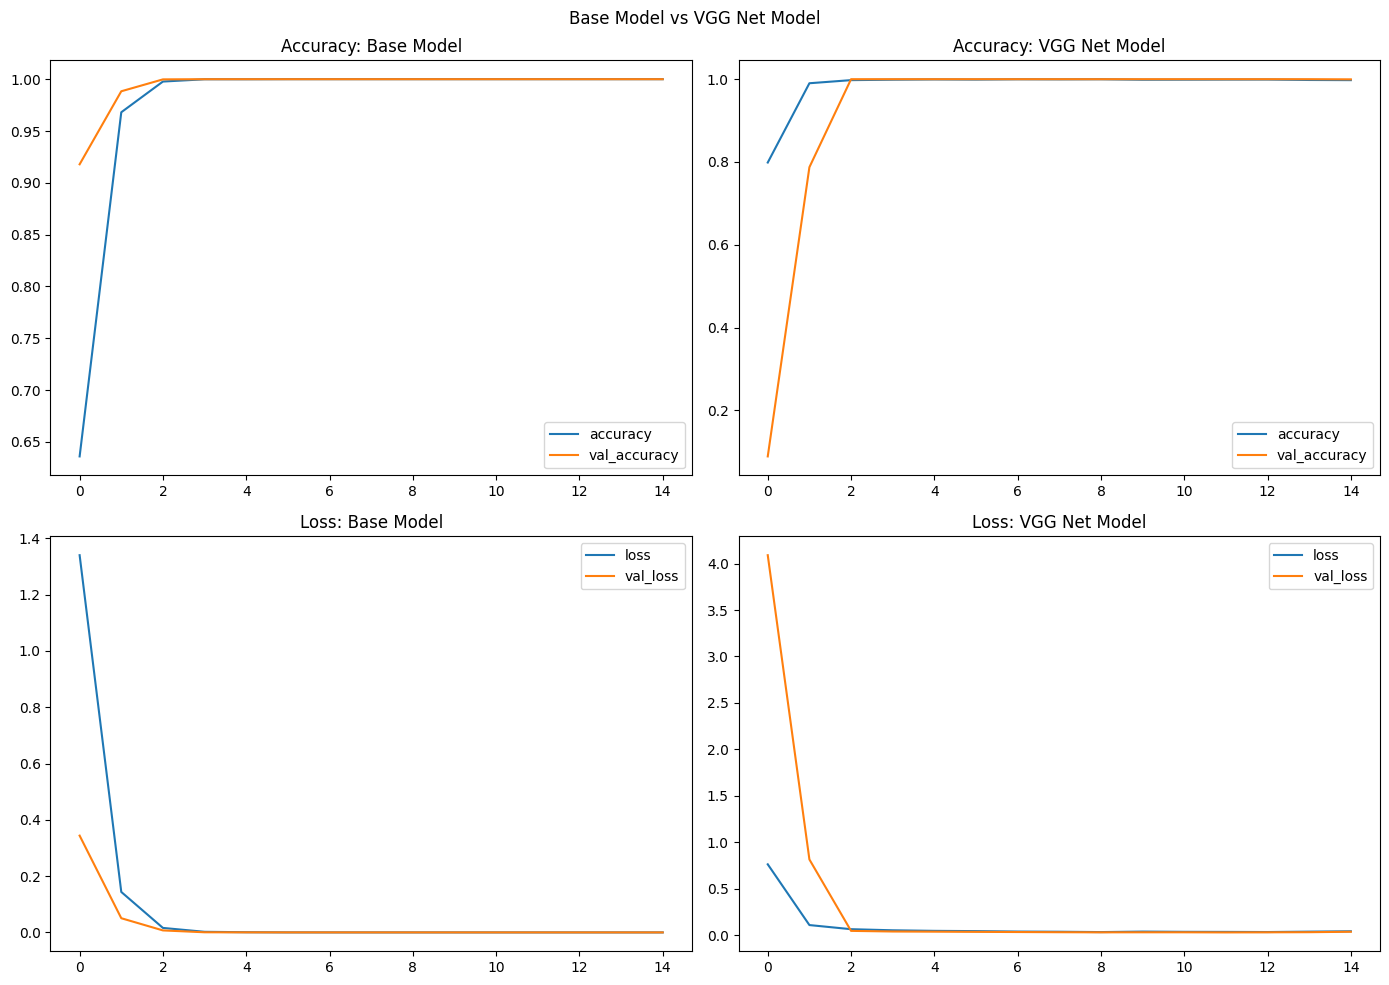

225/225 - 1s - 3ms/step - accuracy: 0.8434 - loss: 1.3685
225/225 - 2s - 9ms/step - accuracy: 0.9543 - loss: 0.1548


In [16]:
fig, ax = plt.subplots(2, 2, figsize=(14,10))
fig.suptitle("Base Model vs VGG Net Model")

ax[0,0].plot(history_base.history['accuracy'], label='accuracy')
ax[0,0].plot(history_base.history['val_accuracy'], label = 'val_accuracy')
ax[0,0].set_title('Accuracy: Base Model')
ax[0,0].legend(loc='lower right')

ax[0,1].plot(history_vgg.history['accuracy'], label='accuracy')
ax[0,1].plot(history_vgg.history['val_accuracy'], label = 'val_accuracy')
ax[0,1].set_title('Accuracy: VGG Net Model')
ax[0,1].legend(loc='lower right')

ax[1,0].plot(history_base.history['loss'], label='loss')
ax[1,0].plot(history_base.history['val_loss'], label = 'val_loss')
ax[1,0].set_title('Loss: Base Model')
ax[1,0].legend(loc='upper right')

ax[1,1].plot(history_vgg.history['loss'], label='loss')
ax[1,1].plot(history_vgg.history['val_loss'], label = 'val_loss')
ax[1,1].set_title('Loss: VGG Net Model')
ax[1,1].legend(loc='upper right')

plt.tight_layout()
plt.show()

test_loss, test_acc = model_base.evaluate(x_test,  y_test, verbose=2)
test_loss, test_acc = model_vgg.evaluate(x_test,  y_test, verbose=2)

**Deliverable 3: Training, Testing, and Evaluation**

In [17]:
y_pred_probs = model_vgg.predict(x_test)
# gives probs
y_pred_labels = np.argmax(y_pred_probs, axis=1)
# predicted class labels

225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step


In [18]:
print("Confusion matrix:")
print(confusion_matrix(y_test, y_pred_labels))
print("\nClassification report:")
print(classification_report(y_test, y_pred_labels))

Confusion matrix:
[[331   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0]
 [  0 432   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0]
 [  0   0 310   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0]
 [  0   0   0 245   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0]
 [  0   0   0   0 478   0   0   0   0   0   0   0   0   0   0   0   0  20
    0   0   0   0   0   0]
 [  0   0   0   0   0 247   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0]
 [  0   0   0   0   0   0 327  14   0   0   0   0   0   0   5   1   0   0
    1   0   0   0   0   0]
 [  0   0   0   0   0   0  41 395   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0 288   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0 290   0   0   0   0   0   0  41   0

In [19]:
prec = precision_score(y_test, y_pred_labels, average="macro")
print("Precision score:", prec)
rec = recall_score(y_test, y_pred_labels, average="macro")
print("Recall score:", rec)
f1 = f1_score(y_test, y_pred_labels, average="macro")
print("F1 score:", f1)

Precision score: 0.9507484340229726
Recall score: 0.9510917057429801
F1 score: 0.9494648146810519


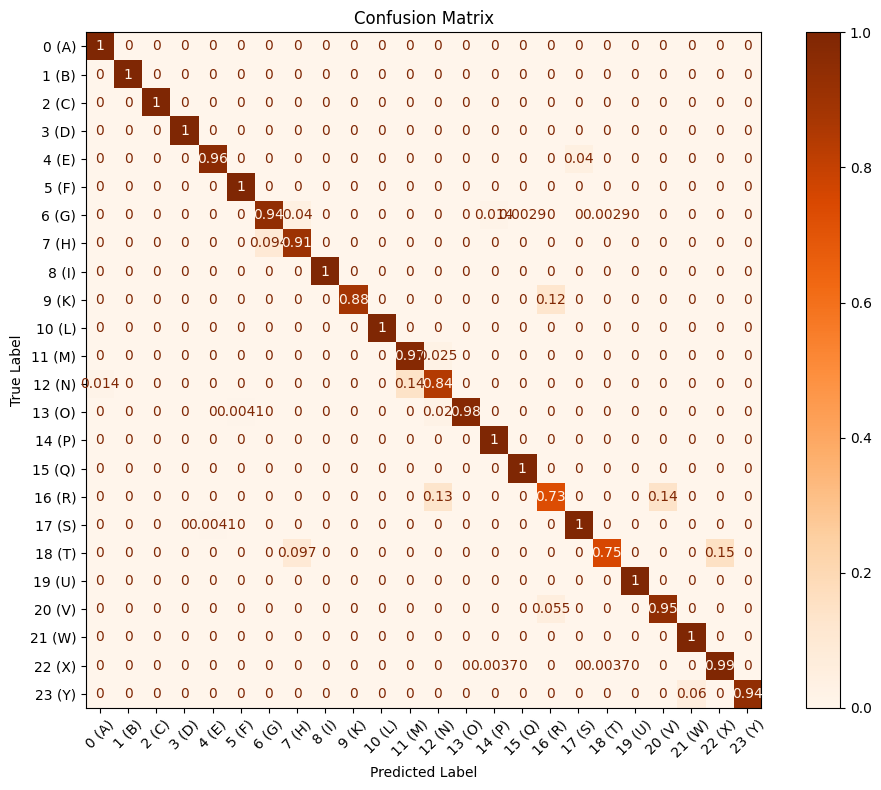

In [20]:
labels = np.unique(y_test)
letters = ['A','B','C','D','E','F','G','H','I','K','L','M','N','O','P','Q','R','S','T','U','V','W','X','Y']
disp_labels = [f"{i} ({letters[i]})" for i in labels]
cm = confusion_matrix(y_test, y_pred_labels, normalize="true")
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=disp_labels)
fig, ax = plt.subplots(figsize=(10,8))
disp.plot(cmap='Oranges', colorbar=True, ax=ax)
ax.set_title("Confusion Matrix")
ax.set_xlabel("Predicted Label")
ax.set_ylabel("True Label")
plt.setp(ax.get_xticklabels(), rotation=45)
plt.tight_layout()
plt.show()


#classes 6 (g) and 7 (h) are harder to classify, often classified as class 19
#class 17 (r) as class 10 (k)
#overall classes 19, 10, 7 have the most errors or higher missclassification rates
#class 13 and class 19 and 24

Step 3.4 (continued):
- Lastly I displayed sample images from the test dataset, that compare the predicted label with the true label. All classes are classified accuratley. I ran the model multiple times, and each run showed each sample image to be identified correctly, reflecting the high precision and recall scores. 

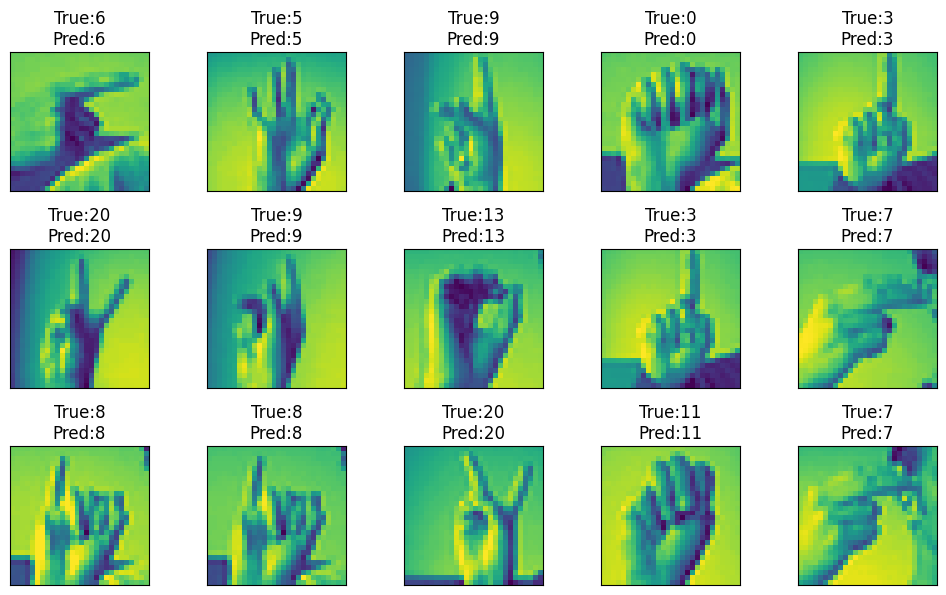

In [21]:
plt.figure(figsize=(10,10))
for i in range(15):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(np.squeeze(x_test[i,:,:,:]))
    plt.title(f"True:{y_test[i]}\nPred:{y_pred_labels[i]}")
    plt.tight_layout()
plt.show()